# 欠拟合与过拟合
**欠拟合（Underfitting）**

欠拟合是指模型过于简单，未能充分学习训练数据中的规律，导致其在训练集和测试集上的表现都很差。
就像一个学生只背了课本的目录，连课堂上讲过的例题都做不对，考试遇到新题更是无从下手。他不是粗心，而是压根没学进去。

**过拟合（Overfitting）**

过拟合是指模型过于复杂，不仅学到了数据中的真实规律，还将噪声也一并记住了，导致其在训练集上表现优异，但在测试集上表现明显下降。
就像一个学生死记硬背了所有课后习题的标准答案，题目稍加变化就束手无策——他记住的是答案本身，而非解题方法。

## 学习曲线
学习曲线是诊断欠拟合/过拟合最直观的工具。它展示了随着训练样本数量增加，训练误差和验证误差的变化趋势。

### 1. 引入必要工具 & 准备数据

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 设置中文字体，解决matplotlib中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# ---------- 数据准备 ----------
np.random.seed(42)  # 设置随机种子，保证结果可复现
n_samples = 100  # 样本数量

# 在[-3, 3]区间均匀采样100个点
X = np.sort(np.random.uniform(-3, 3, n_samples)).reshape(-1, 1)  
# 真实关系: y = x² + 高斯噪声
y = X.ravel() ** 2 + np.random.normal(0, 1, n_samples) 

# ---------- 定义三个不同复杂度的模型 ----------
# degree=1: 线性模型，无法捕捉二次关系，导致欠拟合
# degree=2: 二次多项式，与真实数据生成过程匹配，良好拟合
# degree=15: 高次多项式，过度拟合训练数据中的噪声，导致过拟合
models = {
    "欠拟合 (degree=1)": make_pipeline(PolynomialFeatures(1), LinearRegression()),
    "良好拟合 (degree=2)": make_pipeline(PolynomialFeatures(2), LinearRegression()),
    "过拟合 (degree=15)": make_pipeline(PolynomialFeatures(15), LinearRegression()),
}

### 2. 模型真实值预测曲线图

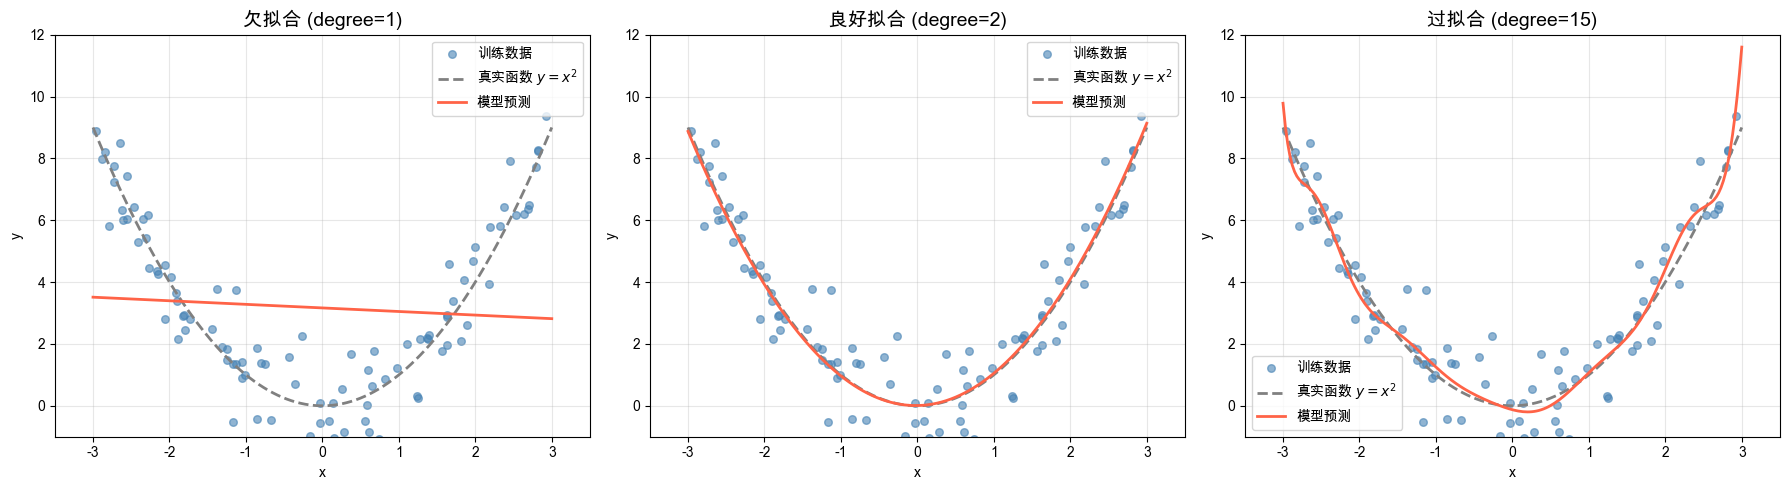

In [ ]:
# 创建1行3列的子图，展示模型的拟合效果
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 用于绘制平滑预测曲线的测试点
X_test = np.linspace(-3, 3, 200).reshape(-1, 1)

for ax, (title, model) in zip(axes, models.items()):
    # 训练模型
    model.fit(X, y)
    
    # 预测
    y_pred = model.predict(X_test)
    
    # 绘制真实数据点（带噪声的样本）
    ax.scatter(X, y, color='steelblue', s=30, alpha=0.6, label='训练数据')
    
    # 绘制真实函数曲线 y = x²
    ax.plot(X_test, X_test.ravel() ** 2, '--', color='gray', linewidth=2, label='真实函数 $y=x^2$')
    
    # 绘制模型预测曲线
    ax.plot(X_test, y_pred, '-', color='tomato', linewidth=2, label='模型预测')
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-1, 12)

plt.tight_layout()
plt.show()

### 3. 学习曲线图

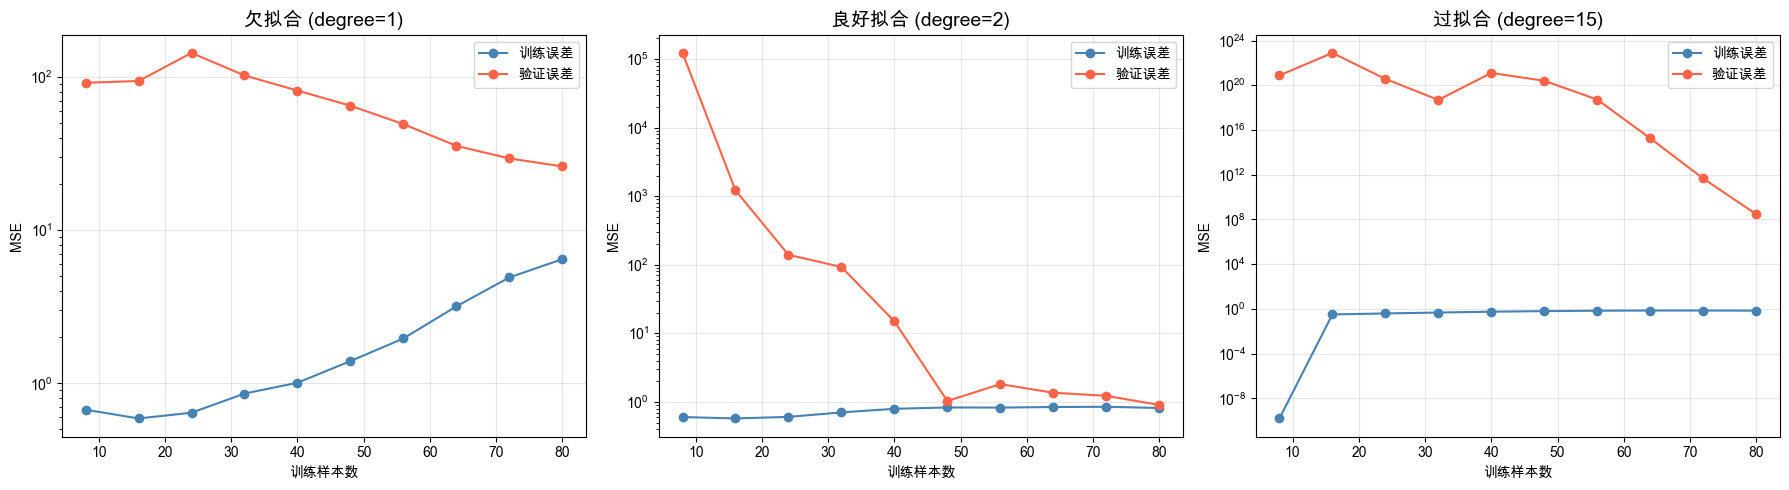

In [ ]:
# 创建1行3列的子图
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 遍历每个模型，绘制学习曲线
for ax, (title, model) in zip(axes, models.items()):
    # learning_curve 返回:
    # - train_sizes: 训练集大小数组
    # - train_scores: 各训练集大小下的训练得分 (shape: [n_sizes, n_cv_folds])
    # - val_scores: 各训练集大小下的验证得分
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        train_sizes=np.linspace(0.1, 1.0, 10),  # 10个训练集大小: 10%, 20%, ..., 100%
        cv=5,  # 5折交叉验证
        scoring="neg_mean_squared_error",  # 使用负均方误差作为评分指标
    )

    # 将负MSE转换为正MSE，并对交叉验证结果取平均
    train_mse = -train_scores.mean(axis=1)
    val_mse   = -val_scores.mean(axis=1)

    # 绘制训练误差曲线
    ax.plot(train_sizes, train_mse, "o-", color="steelblue", label="训练误差")
    # 绘制验证误差曲线
    ax.plot(train_sizes, val_mse,   "o-", color="tomato",    label="验证误差")
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("训练样本数")
    ax.set_ylabel("MSE")
    ax.legend()
    ax.set_yscale("log")  # 使用对数刻度，便于展示差异较大的误差值
    ax.grid(True, alpha=0.3)

plt.tight_layout()  # 自动调整子图间距
plt.show()

## 增加模型复杂性解决欠拟合问题

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

# ========== 加载数据 ==========
housing = fetch_california_housing()
X, y = housing.data, housing.target
feature_names = housing.feature_names

print(f"样本数: {X.shape[0]}, 特征数: {X.shape[1]}")
print(f"特征: {feature_names}")
print(f"目标: 房价中位数（单位：$100,000）\n")

# ========== 使用更复杂的模型 ==========
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
models = {
    "线性回归": make_pipeline(StandardScaler(), LinearRegression()),
    "决策树 (max_depth=5)": DecisionTreeRegressor(max_depth=5, random_state=42),
    "随机森林 (100棵树)": RandomForestRegressor(
        n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
    ),
    "梯度提升树 (GBRT)": GradientBoostingRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42
    ),
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    train_r2 = r2_score(y_train, model.predict(X_train))
    test_r2  = r2_score(y_test,  model.predict(X_test))
    train_mse = mean_squared_error(y_train, model.predict(X_train))
    test_mse  = mean_squared_error(y_test,  model.predict(X_test))

    results.append({
        "模型": name,
        "训练 R²": train_r2,
        "测试 R²": test_r2,
        "训练 MSE": train_mse,
        "测试 MSE": test_mse,
        "差距 (R²)": train_r2 - test_r2,
    })

df_results = pd.DataFrame(results)
print("\n" + "=" * 80)
print("各模型对比：")
print("=" * 80)
print(df_results.to_string(index=False, float_format="%.4f"))

样本数: 20640, 特征数: 8
特征: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
目标: 房价中位数（单位：$100,000）


各模型对比：
               模型  训练 R²  测试 R²  训练 MSE  测试 MSE  差距 (R²)
             线性回归 0.6126 0.5758  0.5179  0.5559   0.0368
决策树 (max_depth=5) 0.6377 0.5997  0.4843  0.5245   0.0379
     随机森林 (100棵树) 0.8719 0.7738  0.1712  0.2965   0.0982
     梯度提升树 (GBRT) 0.9032 0.8288  0.1294  0.2243   0.0744


## 正则化解决过拟合问题

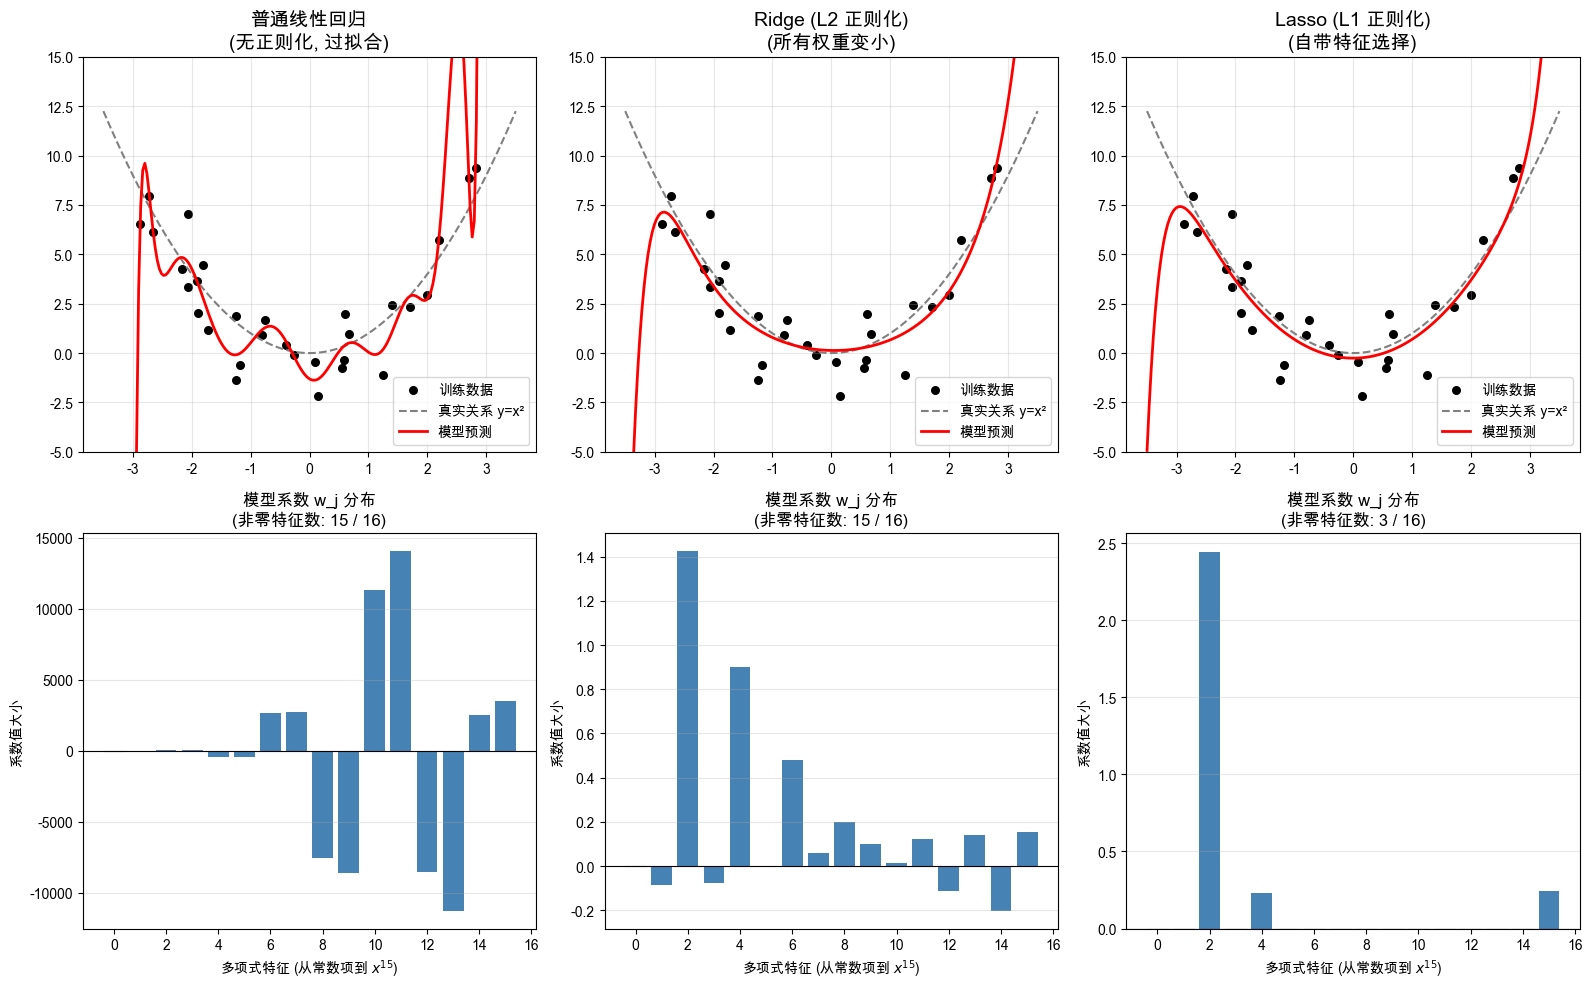

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 生成带噪声的 y = x^2 数据
# ==========================================
np.random.seed(42)
n_samples = 30
X_train = np.sort(np.random.uniform(-3, 3, n_samples)).reshape(-1, 1)
y_train = X_train.ravel()**2 + np.random.normal(0, 1.5, n_samples)

# 用于绘制平滑曲线的测试点
X_plot = np.linspace(-3.5, 3.5, 200).reshape(-1, 1)

# ==========================================
# 2. 定义模型 (15次多项式)
# ==========================================
degree = 15

# 注意：使用正则化时，务必先进行标准化 (StandardScaler)！
# 因为高次项 (如 x^15) 的数值会极其庞大，如果不缩放，正则化惩罚会极不公平。

models = {
    "普通线性回归\n(无正则化, 过拟合)": make_pipeline(
        PolynomialFeatures(degree), StandardScaler(), LinearRegression()
    ),
    "Ridge (L2 正则化)\n(所有权重变小)": make_pipeline(
        PolynomialFeatures(degree), StandardScaler(), Ridge(alpha=5.0)
    ),
    "Lasso (L1 正则化)\n(自带特征选择)": make_pipeline(
        PolynomialFeatures(degree), StandardScaler(), Lasso(alpha=0.2, max_iter=10000)
    )
}

# ==========================================
# 3. 训练模型并可视化结果
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, (name, model) in enumerate(models.items()):
    # 训练模型
    model.fit(X_train, y_train)
    
    # 获取最后一步（回归器）的系数 w_j
    coefs = model.named_steps[model.steps[-1][0]].coef_
    
    # 统计绝对值大于极小值的非零系数个数
    non_zero_count = np.sum(np.abs(coefs) > 1e-5)
    
    # --- 上半部分：绘制拟合曲线 ---
    ax_curve = axes[0, i]
    ax_curve.scatter(X_train, y_train, color='black', s=30, label='训练数据')
    ax_curve.plot(X_plot, X_plot.ravel()**2, '--', color='gray', label='真实关系 y=x²')
    ax_curve.plot(X_plot, model.predict(X_plot), color='red', linewidth=2, label='模型预测')
    
    ax_curve.set_title(name, fontsize=14)
    ax_curve.set_ylim(-5, 15)
    ax_curve.legend()
    ax_curve.grid(True, alpha=0.3)
    
    # --- 下半部分：绘制模型系数 (w0~w15) ---
    ax_coef = axes[1, i]
    # 使用柱状图展示系数大小
    bars = ax_coef.bar(range(len(coefs)), coefs, color='steelblue')
    
    # 把等于 0 的系数标为灰色
    for bar, coef in zip(bars, coefs):
        if abs(coef) < 1e-5:
            bar.set_color('lightgray')
            
    ax_coef.set_title(f"模型系数 w_j 分布\n(非零特征数: {non_zero_count} / {len(coefs)})", fontsize=12)
    ax_coef.set_xlabel("多项式特征 (从常数项到 $x^{15}$)")
    ax_coef.set_ylabel("系数值大小")
    ax_coef.axhline(0, color='black', linewidth=0.8)
    ax_coef.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()